In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

# Scikit-learn imports
from sklearn.model_selection import train_test_split, RandomizedSearchCV, learning_curve, validation_curve, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, average_precision_score, classification_report
from sklearn.neural_network import MLPClassifier

# XGBoost
import xgboost as xgb

import warnings
warnings.filterwarnings('ignore')

# 1. Load Bank Marketing Dataset
print("Loading data...")
url = "bank-additional-full.csv"
data = pd.read_csv(url, sep=';')

# 2. Handle missing values
for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = data[col].replace('unknown', data[col].mode()[0])

# 3. Encode categorical variables
le = LabelEncoder()
data['y'] = le.fit_transform(data['y'])

# One-hot encoding
X = pd.get_dummies(data.drop('y', axis=1), drop_first=True)
y = data['y']

# 4. Split data (random_state=42 for reproducibility)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=(0.15/0.85), random_state=42, stratify=y_temp)

# 5. Feature Scaling (Mandatory for MLP)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for XGBoost to preserve feature names for importance plotting
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X_val.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print(f"Data shapes - Train: {X_train_scaled.shape}, Val: {X_val_scaled.shape}, Test: {X_test_scaled.shape}")

Loading data...
Data shapes - Train: (28830, 47), Val: (6179, 47), Test: (6179, 47)


Performing Hyperparameter Tuning for GBDT...
Best GBDT Parameters: {'subsample': 0.8, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 1.0}

Training optimized GBDT with early stopping...


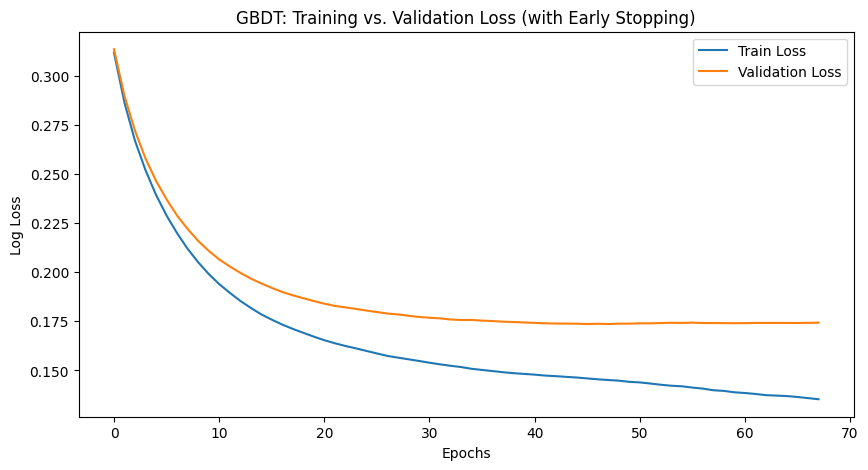

<Figure size 1000x600 with 0 Axes>

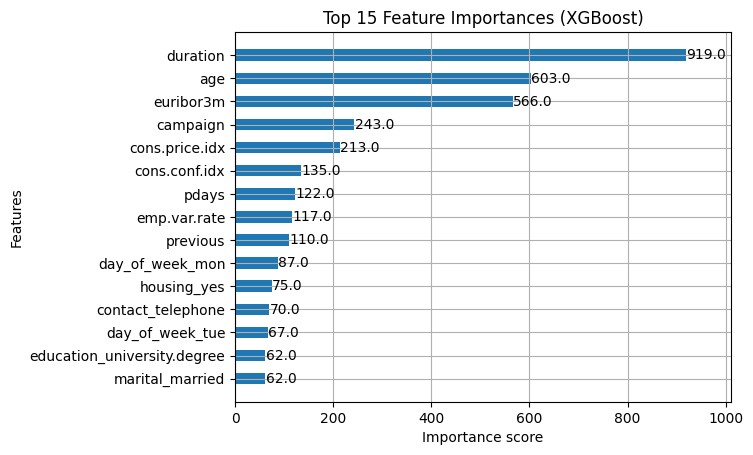

Generating learning rate comparison plot...


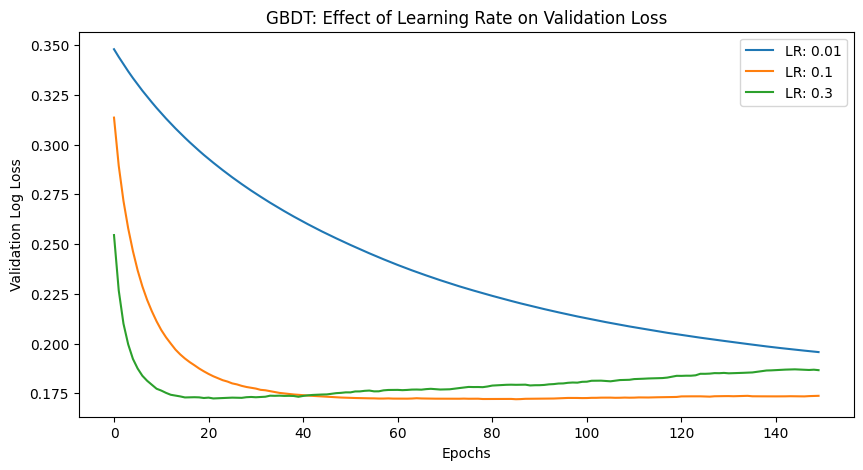

In [2]:
print("Performing Hyperparameter Tuning for GBDT...")

# 1. Hyperparameter Tuning using RandomizedSearchCV
param_distributions_xgb = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb.XGBClassifier(n_estimators=100, random_state=42),
    param_distributions=param_distributions_xgb,
    n_iter=5, cv=3, scoring='f1', random_state=42, n_jobs=-1
)
xgb_search.fit(X_train_scaled, y_train)
print(f"Best GBDT Parameters: {xgb_search.best_params_}")

# 2. Train Best Model with eval_set and early_stopping_rounds
print("\nTraining optimized GBDT with early stopping...")
start_time_xgb = time.time()
best_xgb_model = xgb.XGBClassifier(
    **xgb_search.best_params_,
    n_estimators=500,
    random_state=42,
    early_stopping_rounds=20
)

best_xgb_model.fit(
    X_train_scaled, y_train,
    eval_set=[(X_train_scaled, y_train), (X_val_scaled, y_val)],
    verbose=False
)
xgb_train_time = time.time() - start_time_xgb

# 3. Visualization: Training vs. Validation Loss
results = best_xgb_model.evals_result()
epochs = len(results['validation_0']['logloss'])

plt.figure(figsize=(10, 5))
plt.plot(range(0, epochs), results['validation_0']['logloss'], label='Train Loss')
plt.plot(range(0, epochs), results['validation_1']['logloss'], label='Validation Loss')
plt.legend()
plt.ylabel('Log Loss')
plt.xlabel('Epochs')
plt.title('GBDT: Training vs. Validation Loss (with Early Stopping)')
plt.show()

# 4. Visualization: Top Feature Importances
plt.figure(figsize=(10, 6))
xgb.plot_importance(best_xgb_model, max_num_features=15, height=0.5, importance_type='weight')
plt.title('Top 15 Feature Importances (XGBoost)')
plt.show()

# 5. Visualization: Effect of Learning Rate on Validation Loss
print("Generating learning rate comparison plot...")
learning_rates = [0.01, 0.1, 0.3]
plt.figure(figsize=(10, 5))

for lr in learning_rates:
    lr_model = xgb.XGBClassifier(n_estimators=150, learning_rate=lr, random_state=42)
    lr_model.fit(X_train_scaled, y_train, eval_set=[(X_val_scaled, y_val)], verbose=False)
    val_loss = lr_model.evals_result()['validation_0']['logloss']
    plt.plot(range(len(val_loss)), val_loss, label=f'LR: {lr}')

plt.legend()
plt.ylabel('Validation Log Loss')
plt.xlabel('Epochs')
plt.title('GBDT: Effect of Learning Rate on Validation Loss')
plt.show()

# Final Predictions
y_pred_xgb = best_xgb_model.predict(X_test_scaled)
y_prob_xgb = best_xgb_model.predict_proba(X_test_scaled)[:, 1]

Training and Tuning MLP architectures...


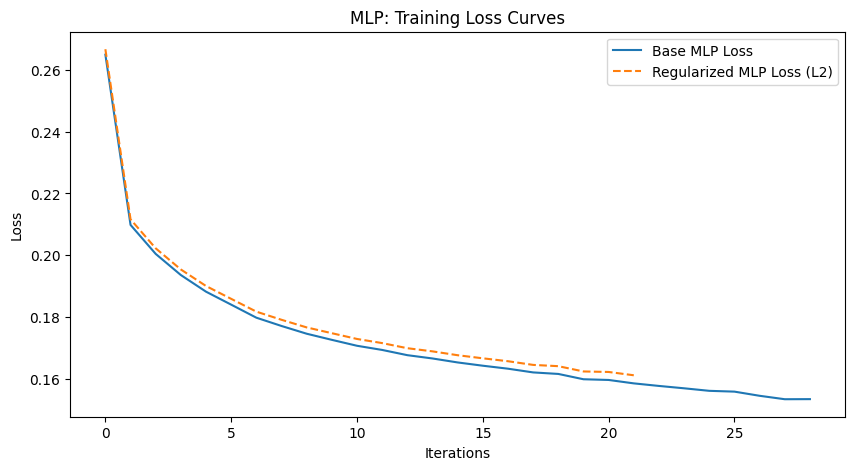

Generating network architecture comparison plot...


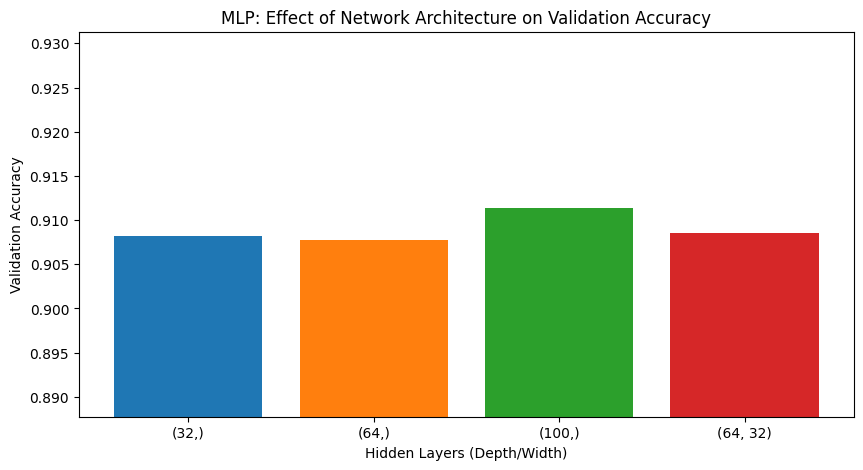


Performing Hyperparameter Tuning for MLP...
Best MLP Parameters: {'learning_rate_init': 0.001, 'hidden_layer_sizes': (50,), 'alpha': 0.01, 'activation': 'tanh'}


In [3]:
print("Training and Tuning MLP architectures...")

# 1. Base vs Regularized models for loss_curve_ visualization
mlp_base = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42, early_stopping=True)
mlp_base.fit(X_train_scaled, y_train)

mlp_regularized = MLPClassifier(hidden_layer_sizes=(100,), alpha=0.01, max_iter=500, random_state=42, early_stopping=True)
mlp_regularized.fit(X_train_scaled, y_train)

# 2. Visualization: Access loss_curve_ for training loss
plt.figure(figsize=(10, 5))
plt.plot(mlp_base.loss_curve_, label="Base MLP Loss")
plt.plot(mlp_regularized.loss_curve_, label="Regularized MLP Loss (L2)", linestyle='--')
plt.title('MLP: Training Loss Curves')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend()
plt.show()

# 3. Visualization: Effect of Network Depth/Width on Validation Performance
print("Generating network architecture comparison plot...")
architectures = [(32,), (64,), (100,), (64, 32)]
arch_labels = [str(a) for a in architectures]
val_accuracies = []

for arch in architectures:
    arch_model = MLPClassifier(hidden_layer_sizes=arch, max_iter=200, random_state=42, early_stopping=True)
    arch_model.fit(X_train_scaled, y_train)
    val_accuracies.append(accuracy_score(y_val, arch_model.predict(X_val_scaled)))

plt.figure(figsize=(10, 5))
plt.bar(arch_labels, val_accuracies, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
plt.ylim(min(val_accuracies) - 0.02, max(val_accuracies) + 0.02)
plt.title('MLP: Effect of Network Architecture on Validation Accuracy')
plt.xlabel('Hidden Layers (Depth/Width)')
plt.ylabel('Validation Accuracy')
plt.show()

# 4. Hyperparameter Tuning using RandomizedSearchCV
print("\nPerforming Hyperparameter Tuning for MLP...")
start_time_mlp = time.time()
param_distributions_mlp = {
    'hidden_layer_sizes': [(50,), (100,), (64, 32)],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.01],
    'activation': ['relu', 'tanh']
}

mlp_search = RandomizedSearchCV(
    estimator=MLPClassifier(max_iter=200, random_state=42, early_stopping=True),
    param_distributions=param_distributions_mlp,
    n_iter=5, cv=3, scoring='f1', random_state=42, n_jobs=-1
)
mlp_search.fit(X_train_scaled, y_train)
mlp_train_time = time.time() - start_time_mlp
print(f"Best MLP Parameters: {mlp_search.best_params_}")

best_mlp_model = mlp_search.best_estimator_

# Final Predictions
y_pred_mlp = best_mlp_model.predict(X_test_scaled)
y_prob_mlp = best_mlp_model.predict_proba(X_test_scaled)[:, 1]

Generating Scikit-Learn Diagnostic Curves...


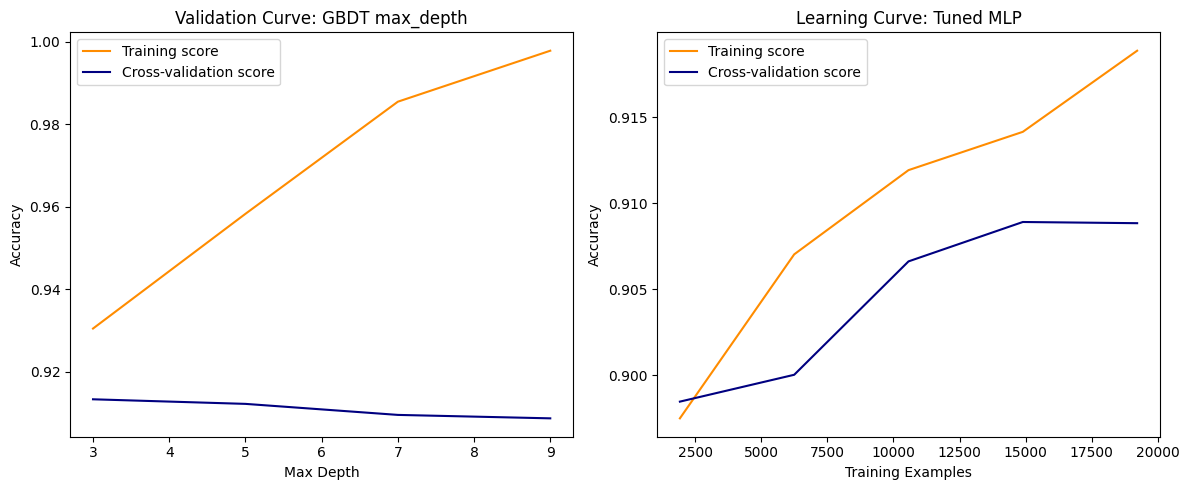

In [4]:
print("Generating Scikit-Learn Diagnostic Curves...")

# 1. Validation Curve for GBDT (max_depth)
param_range = [3, 5, 7, 9]
train_scores_vc, test_scores_vc = validation_curve(
    xgb.XGBClassifier(n_estimators=100, random_state=42),
    X_train_scaled, y_train,
    param_name="max_depth",
    param_range=param_range,
    cv=3, scoring="accuracy", n_jobs=-1
)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(param_range, np.mean(train_scores_vc, axis=1), label="Training score", color="darkorange")
plt.plot(param_range, np.mean(test_scores_vc, axis=1), label="Cross-validation score", color="navy")
plt.title("Validation Curve: GBDT max_depth")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.legend(loc="best")

# 2. Learning Curve for Tuned MLP
train_sizes, train_scores_lc, test_scores_lc = learning_curve(
    best_mlp_model, X_train_scaled, y_train,
    train_sizes=np.linspace(0.1, 1.0, 5), cv=3, scoring='accuracy', n_jobs=-1
)

plt.subplot(1, 2, 2)
plt.plot(train_sizes, np.mean(train_scores_lc, axis=1), label="Training score", color="darkorange")
plt.plot(train_sizes, np.mean(test_scores_lc, axis=1), label="Cross-validation score", color="navy")
plt.title("Learning Curve: Tuned MLP")
plt.xlabel("Training Examples")
plt.ylabel("Accuracy")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

In [6]:
print("=== Extended Evaluation Metrics ===")

print("\n[ Tuned GBDT Classification Report ]")
print(classification_report(y_test, y_pred_xgb))

print("\n[ Tuned MLP Classification Report ]")
print(classification_report(y_test, y_pred_mlp))

print("\n=== Robust Cross-Validation (cross_val_score) ===")
# FIX: Create fresh models for CV without early stopping constraints that break scikit-learn's internal fit
cv_xgb_model = xgb.XGBClassifier(**xgb_search.best_params_, n_estimators=100, random_state=42)
cv_mlp_model = MLPClassifier(**mlp_search.best_params_, max_iter=200, random_state=42)

# Utilizing cross_val_score on the full training set for a robust F1 estimate
cv_f1_xgb = cross_val_score(cv_xgb_model, X_train_scaled, y_train, cv=3, scoring='f1', n_jobs=-1).mean()
cv_f1_mlp = cross_val_score(cv_mlp_model, X_train_scaled, y_train, cv=3, scoring='f1', n_jobs=-1).mean()

print(f"GBDT 3-Fold CV F1-Score: {cv_f1_xgb:.4f}")
print(f"MLP 3-Fold CV F1-Score: {cv_f1_mlp:.4f}")

print("\n=== Final Test Set Comparison Summary ===")
comparison_df = pd.DataFrame({
    'Tuned GBDT (XGBoost)': [
        accuracy_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_xgb),
        average_precision_score(y_test, y_prob_xgb),
        xgb_train_time
    ],
    'Tuned MLP (Neural Network)': [
        accuracy_score(y_test, y_pred_mlp),
        precision_score(y_test, y_pred_mlp),
        recall_score(y_test, y_pred_mlp),
        f1_score(y_test, y_pred_mlp),
        average_precision_score(y_test, y_prob_mlp),
        mlp_train_time
    ]
}, index=['Accuracy', 'Precision', 'Recall', 'F1-score', 'AUC-PR', 'Tuning & Training Time (s)'])

display(comparison_df)

=== Extended Evaluation Metrics ===

[ Tuned GBDT Classification Report ]
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      5483
           1       0.68      0.57      0.62       696

    accuracy                           0.92      6179
   macro avg       0.81      0.77      0.79      6179
weighted avg       0.92      0.92      0.92      6179


[ Tuned MLP Classification Report ]
              precision    recall  f1-score   support

           0       0.94      0.97      0.95      5483
           1       0.67      0.50      0.57       696

    accuracy                           0.92      6179
   macro avg       0.80      0.74      0.76      6179
weighted avg       0.91      0.92      0.91      6179


=== Robust Cross-Validation (cross_val_score) ===
GBDT 3-Fold CV F1-Score: 0.5875
MLP 3-Fold CV F1-Score: 0.5056

=== Final Test Set Comparison Summary ===


,Tuned GBDT (XGBoost),Tuned MLP (Neural Network)
Accuracy,0.921670,0.915844
Precision,0.682759,0.667939
Recall,0.568966,0.502874
F1-score,0.620690,0.573770
AUC-PR,0.690816,0.651535
Tuning & Training Time (s),0.306380,8.629828
